# Six-Face Test: Statistical Analysis

Use this notebook to review results from the six-face test captures made with the `1-dataCapture.ipynb` notebook, compare the resulting histograms directly, and compute statistics to inform calibration decisions.

## Setup

In [1]:
from statistics import fmean, pstdev
from signal_utils import IMUSampleReader

import matplotlib.pyplot as plt

G = 9.80665

reader = IMUSampleReader()


def plotOrientationHistogramsFromCsv(
    fileName: str, title: str, accelReferences: dict[str, float]
) -> None:
    motionData = reader.read(fileName)
    _plotOrientationHistograms(motionData, title, accelReferences)


def _plotOrientationHistograms(
    motion_data, title: str, accel_references: dict[str, float]
) -> None:
    if len(motion_data["seq"]) == 0:
        raise ValueError("No samples available for plotting.")

    fig, axes = plt.subplots(3, 2, figsize=(16, 12))

    axes[0, 0].set_title("Linear Acceleration")
    accelPlots = [
        (
            axes[0, 0],
            motion_data["a"]["x"],
            accel_references["x"],
            "x (m/s^2)",
        ),
        (
            axes[1, 0],
            motion_data["a"]["y"],
            accel_references["y"],
            "y (m/s^2)",
        ),
        (
            axes[2, 0],
            motion_data["a"]["z"],
            accel_references["z"],
            "z (m/s^2)",
        ),
    ]

    axes[0, 1].set_title("Angular Velocity")
    gyroPlots = [
        (axes[0, 1], motion_data["w"]["roll"], 0.0, "roll (deg/s)"),
        (axes[1, 1], motion_data["w"]["pitch"], 0.0, "pitch (deg/s)"),
        (axes[2, 1], motion_data["w"]["yaw"], 0.0, "yaw (deg/s)"),
    ]

    for axis, values, reference, horizontalLabel in accelPlots:
        _plotDistribution(
            axis,
            values,
            reference,
            horizontalLabel,
        )

    for axis, values, reference, horizontalLabel in gyroPlots:
        _plotDistribution(
            axis,
            values,
            reference,
            horizontalLabel,
        )

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def _plotDistribution(axis, values, reference, horizontalLabel):
    axis.set_xlabel(horizontalLabel)
    axis.set_ylabel("count")
    axis.grid(alpha=0.25)

    if len(values) == 0:
        axis.text(
            0.5, 0.5, "No samples", transform=axis.transAxes, ha="center", va="center"
        )
        return

    mean = fmean(values) if len(values) > 0 else 0.0
    std = pstdev(values) if len(values) > 1 else 0.0

    axis.hist(values, bins=20)
    axis.axvline(
        reference,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label=f"reference = {_formatReference(reference)}",
    )
    axis.axvline(
        mean,
        color="crimson",
        linestyle="-",
        linewidth=1.5,
        label=f"mean = {mean:.3f}",
    )
    axis.plot([], [], linestyle="", label=f"std = {std:.3f}")
    axis.legend(loc="upper right")


def _formatReference(reference: float) -> str:
    if abs(reference - G) < 1e-9:
        return "+g"
    if abs(reference + G) < 1e-9:
        return "-g"
    return f"{reference:.3f}"

## Histograms

### Orientation 1: +X Up

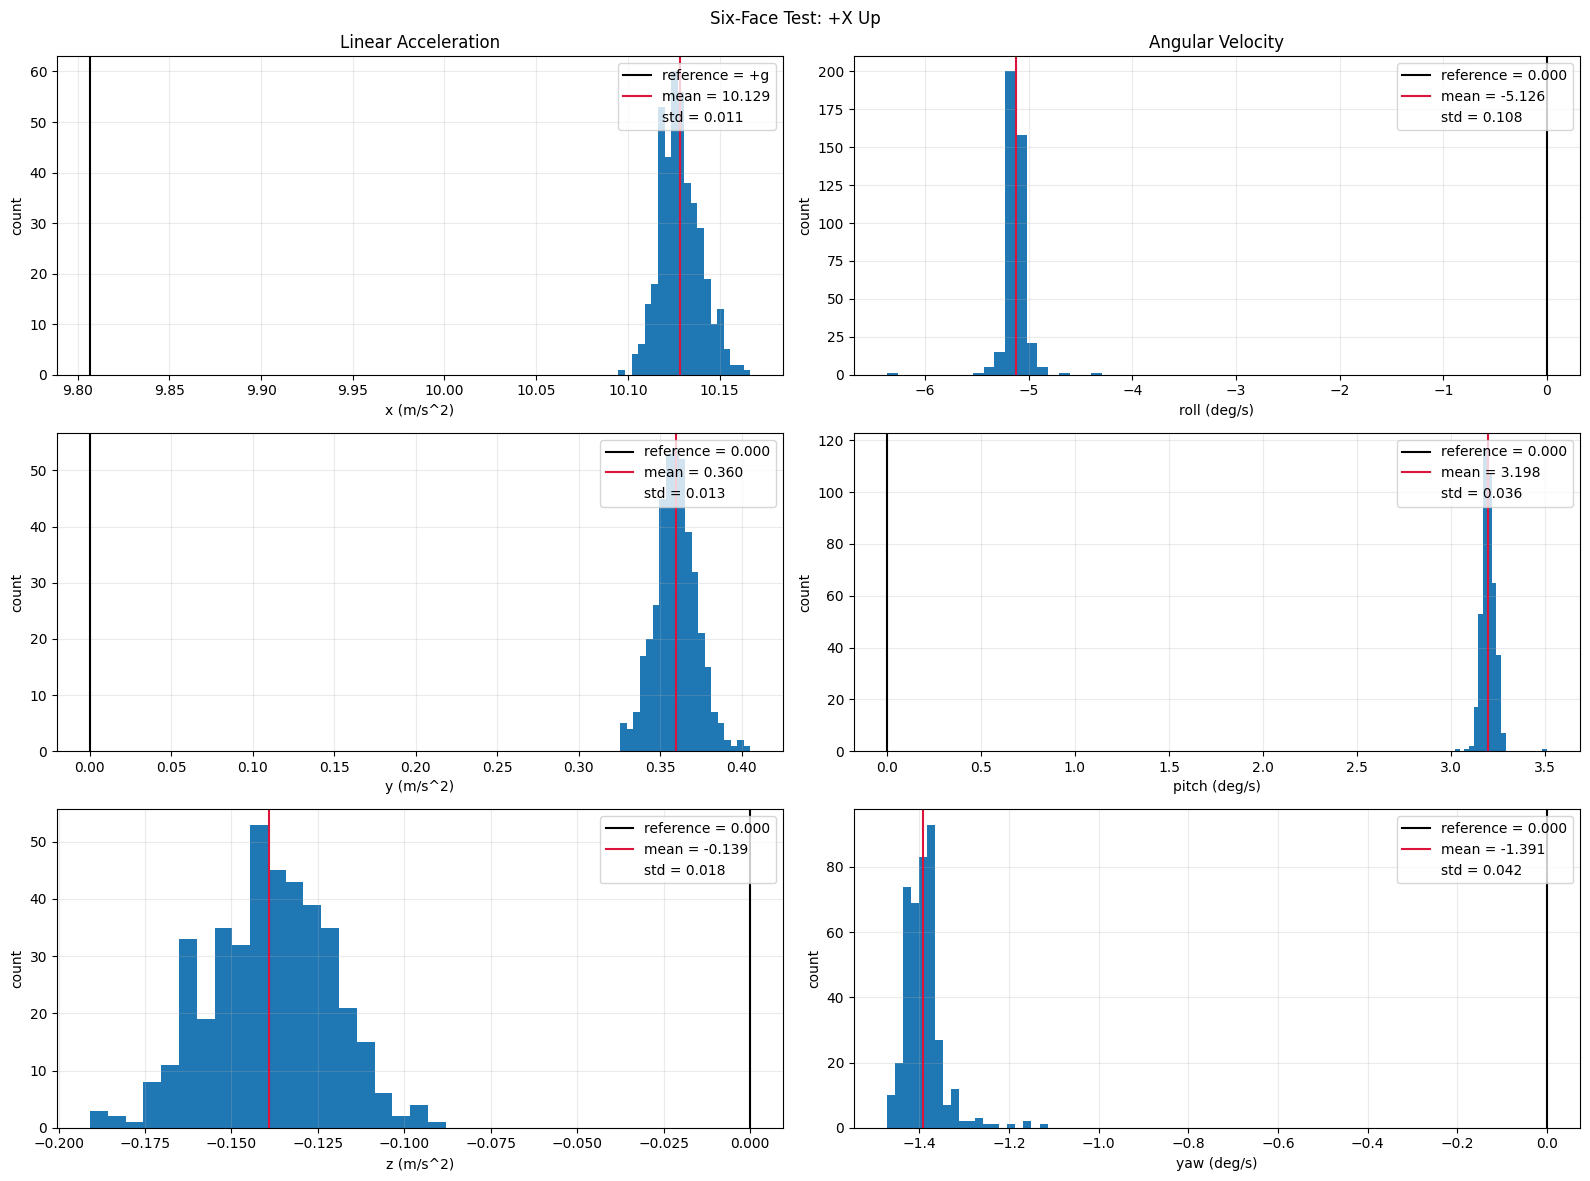

In [2]:
plotOrientationHistogramsFromCsv(
    "./capture/positive-x-up.csv",
    title="Six-Face Test: +X Up",
    accelReferences={"x": G, "y": 0.0, "z": 0.0},
)

### Orientation 2: -X Up

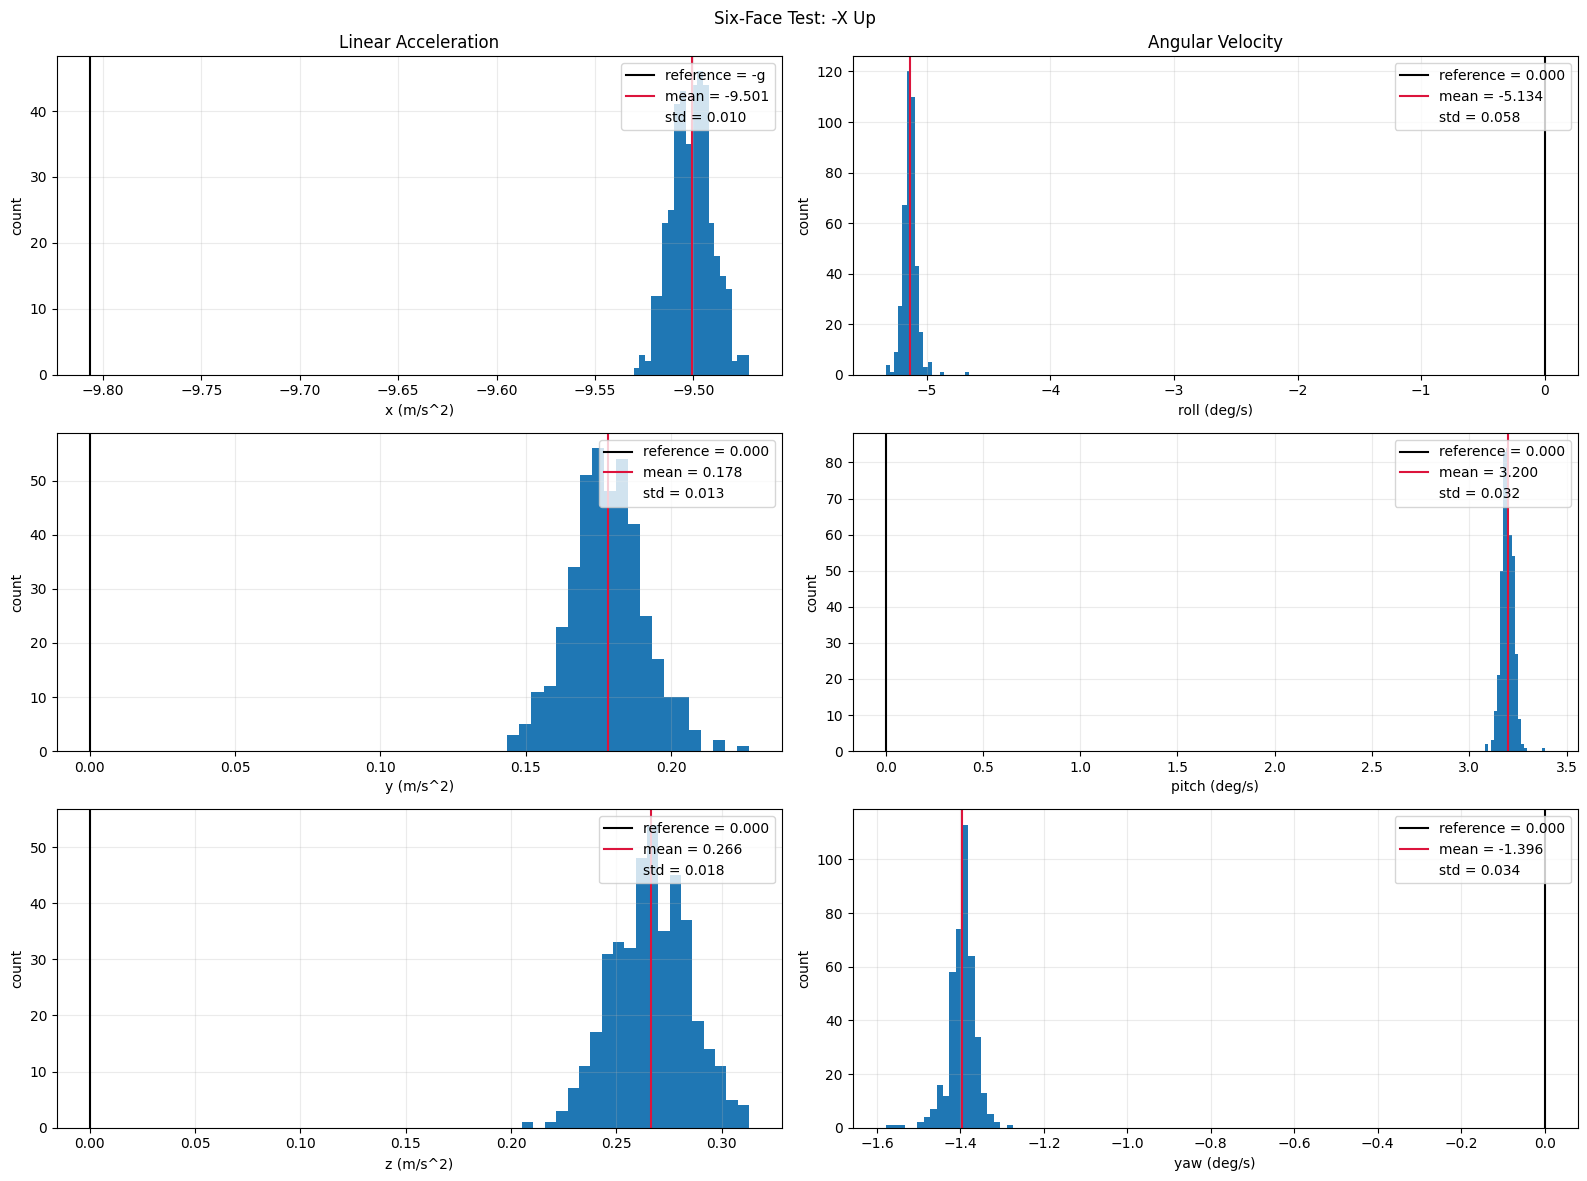

In [3]:
plotOrientationHistogramsFromCsv(
    "./capture/negative-x-up.csv",
    title="Six-Face Test: -X Up",
    accelReferences={"x": -G, "y": 0.0, "z": 0.0},
)

### Orientation 3: +Y Up

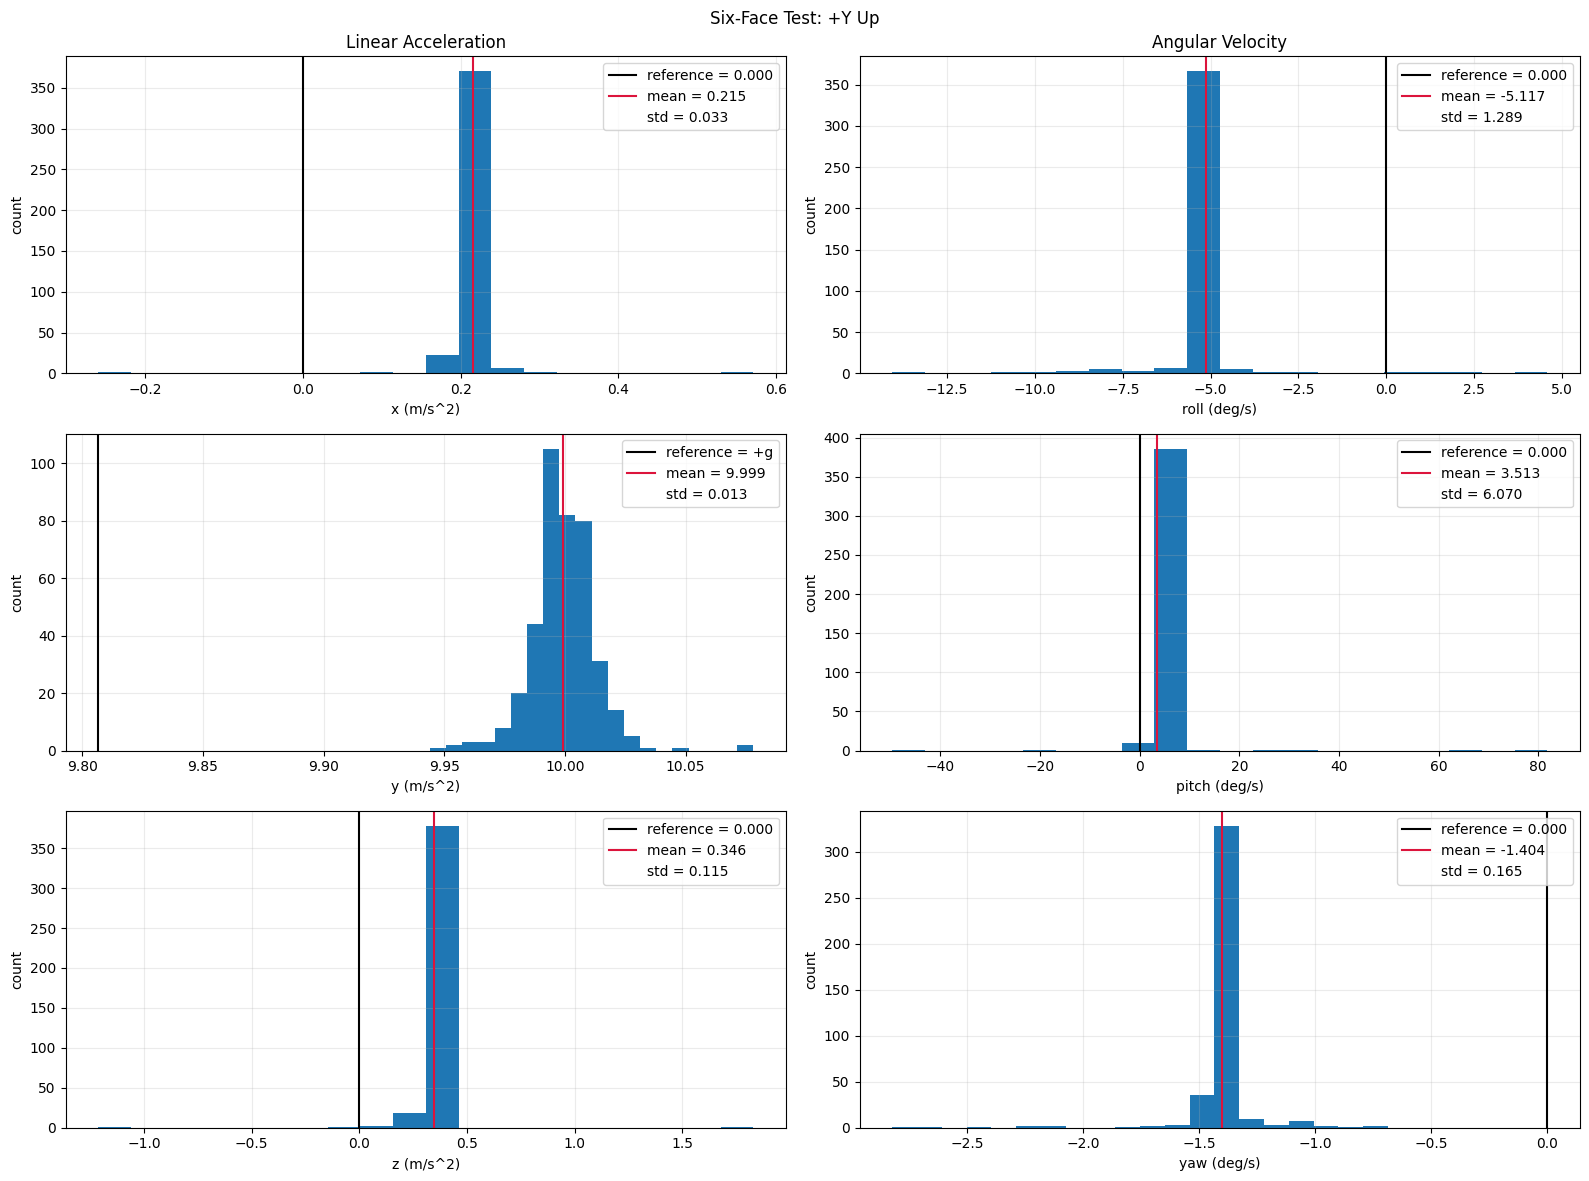

In [4]:
plotOrientationHistogramsFromCsv(
    "./capture/positive-y-up.csv",
    title="Six-Face Test: +Y Up",
    accelReferences={"x": 0.0, "y": G, "z": 0.0},
)

### Orientation 4: -Y Up

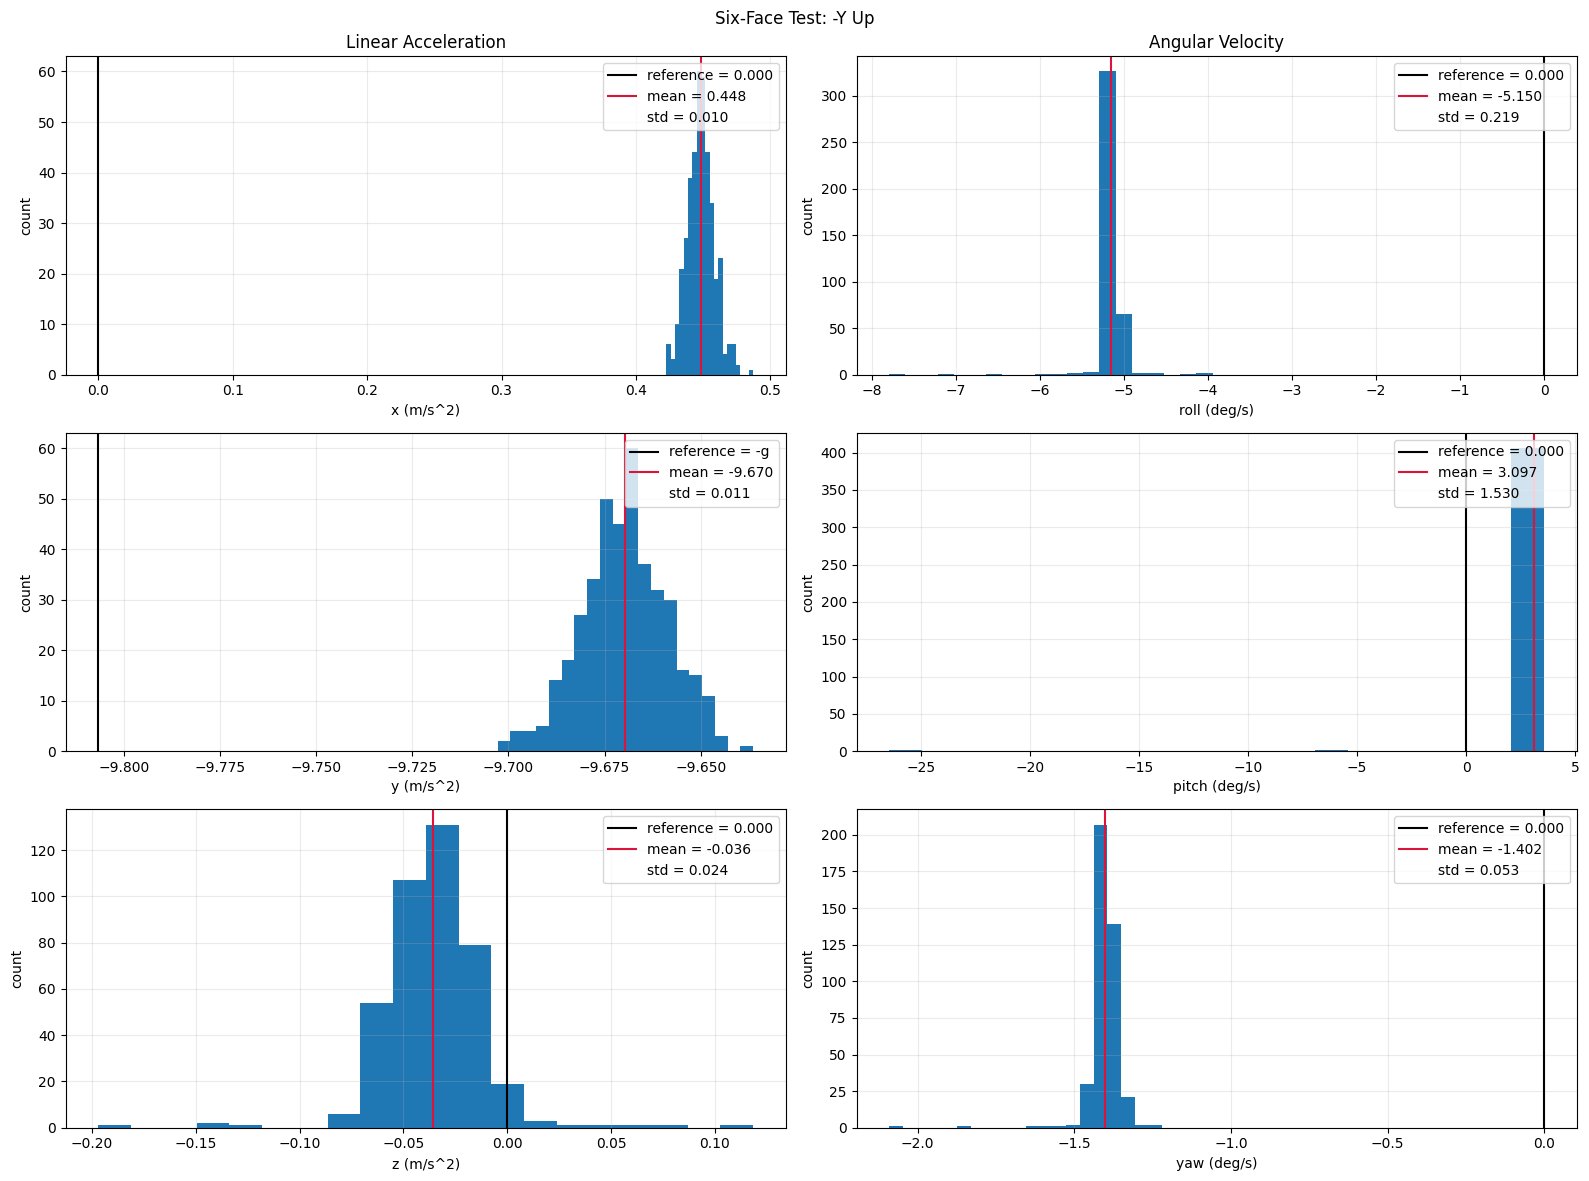

In [5]:
plotOrientationHistogramsFromCsv(
    "./capture/negative-y-up.csv",
    title="Six-Face Test: -Y Up",
    accelReferences={"x": 0.0, "y": -G, "z": 0.0},
)

### Orientation 5: +Z Up

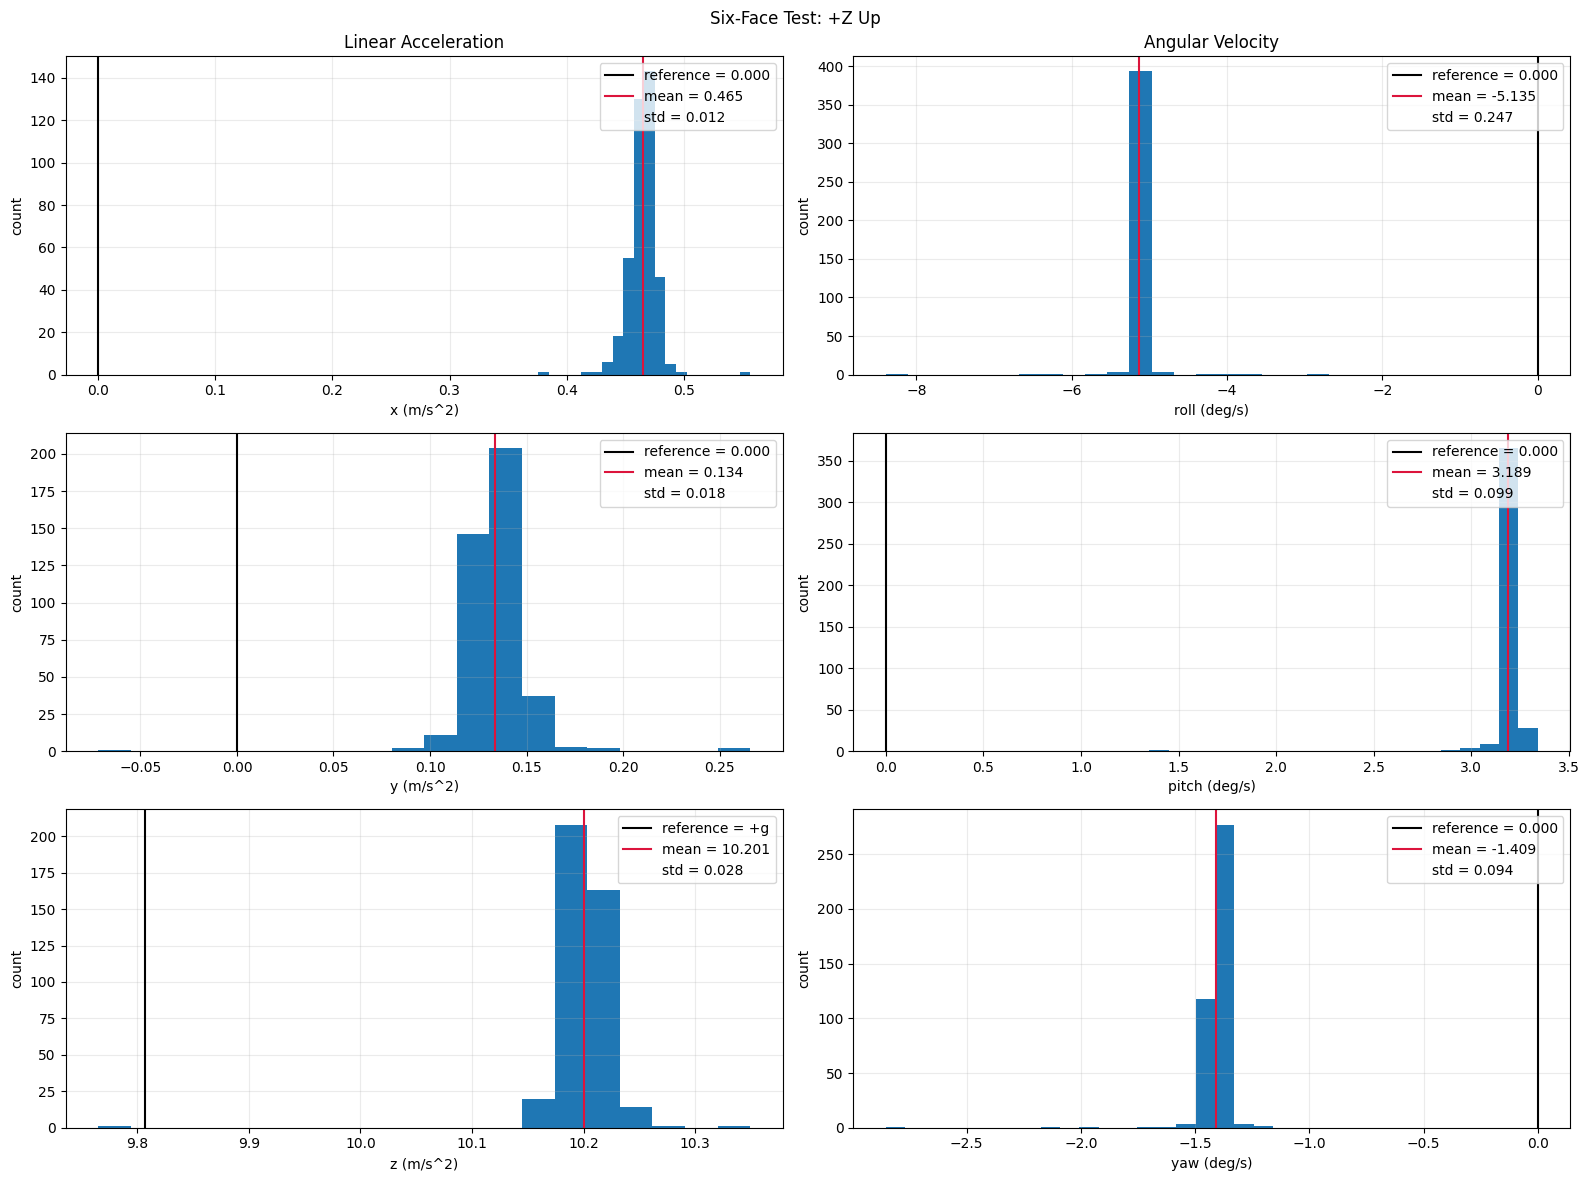

In [6]:
plotOrientationHistogramsFromCsv(
    "./capture/positive-z-up.csv",
    title="Six-Face Test: +Z Up",
    accelReferences={"x": 0.0, "y": 0.0, "z": G},
)

### Orientation 6: -Z Up

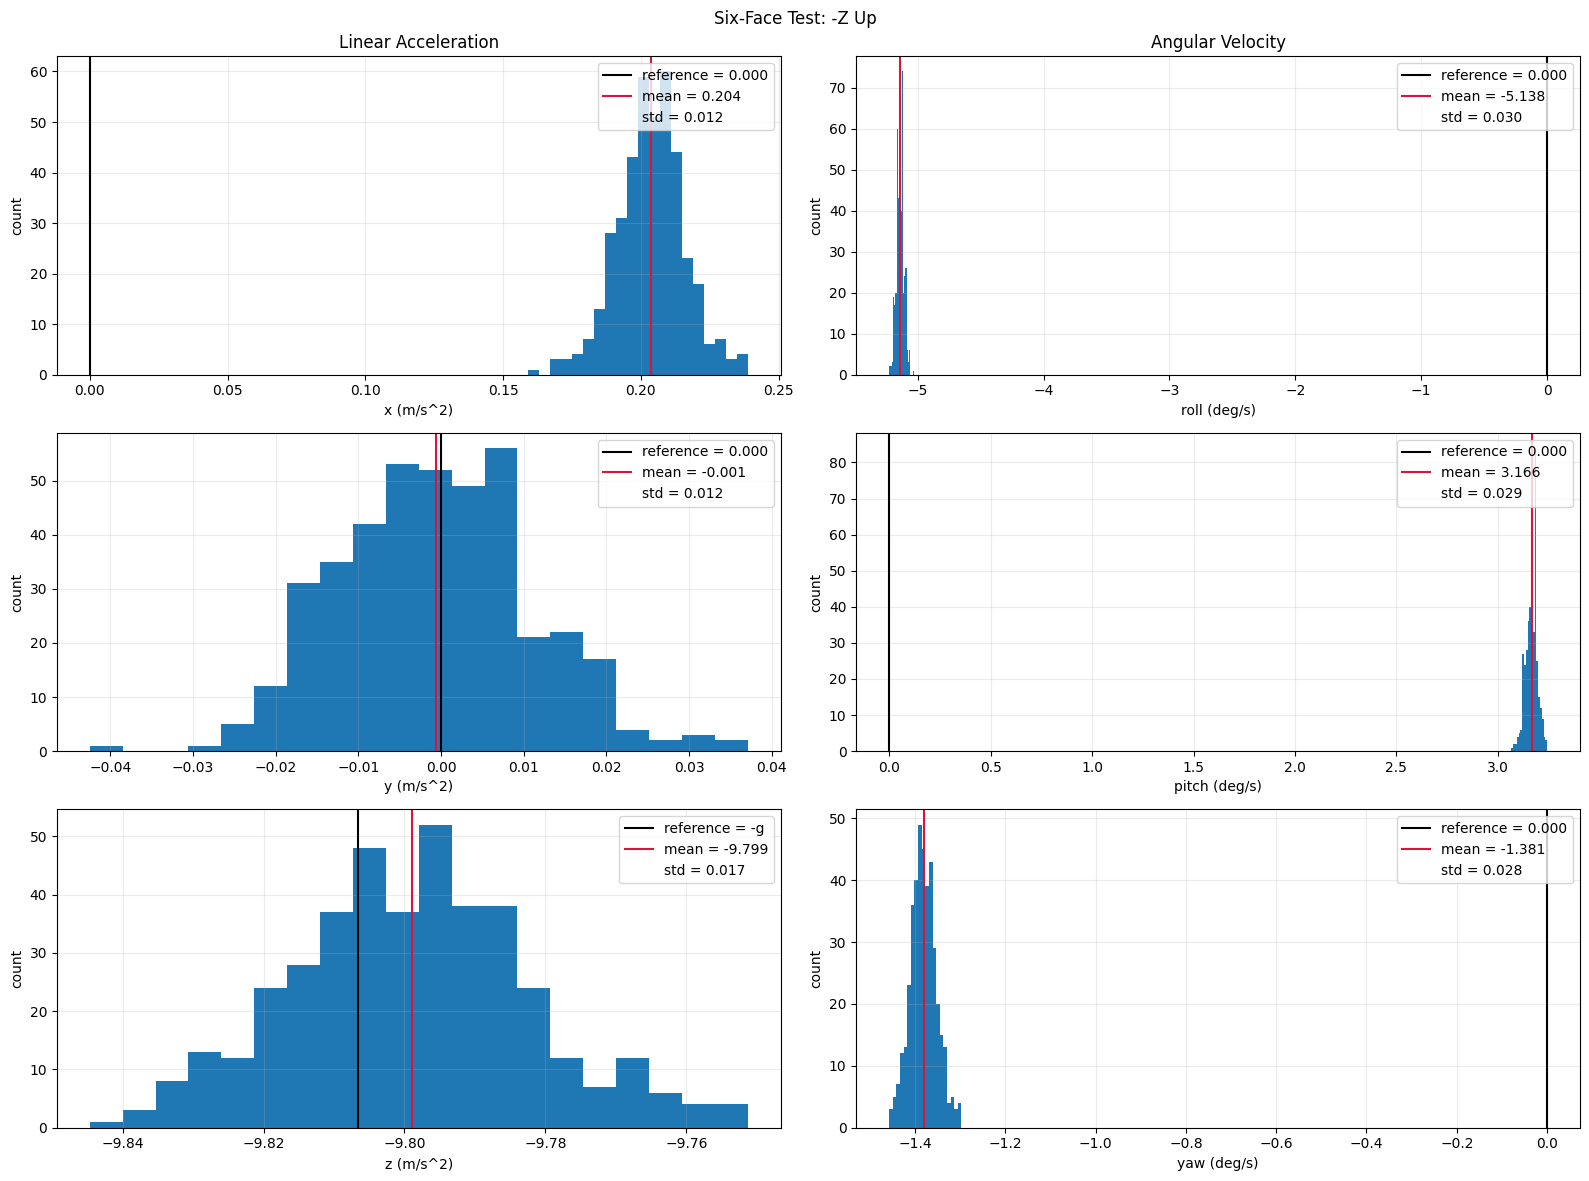

In [7]:
plotOrientationHistogramsFromCsv(
    "./capture/negative-z-up.csv",
    title="Six-Face Test: -Z Up",
    accelReferences={"x": 0.0, "y": 0.0, "z": -G},
)